# IAI600 Lab 01 — Data Exploration, Cleaning and Feature Preparation

**Dataset:** California Housing  
**Course text:** Chapter 2 — End-to-end Machine Learning project

This notebook covers the stages that come before training a model.
Model training and selection are done in Lab II.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

print("imports ok")

imports ok


In [2]:
from pathlib import Path
import urllib.request

DATA_DIR = Path("../data")
DATA_DIR.mkdir(exist_ok=True)
csv_path = DATA_DIR / "housing.csv"

if not csv_path.exists():
    url = "https://raw.githubusercontent.com/ageron/data/main/housing/housing.csv"
    urllib.request.urlretrieve(url, csv_path)
    print("Downloaded to", csv_path)
else:
    print("Using existing file:", csv_path)

housing = pd.read_csv(csv_path)
print(housing.shape)

Using existing file: ..\data\housing.csv
(20640, 10)


In [3]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [5]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Task 2.1 - Understand the Dataset

**1. How many observations are contained in the dataset?**
**Answer:** There are 20640 observations. One observation represents a district in California.

**2. How many attributes are available?**
**Answer:** There are 10 attributes (columns). 9 input attributes and 1 target variable.

**3. Which attributes are numerical?**
**Answer:** All attributes are numerical, except the `ocean_proximity` attribute. The data type column in `housing.info()` shows all 9 columns have float64 Dtype and `ocean_proximity` has a Dtype of str.

**4. Which attribute is categorical?**
**Answer:** The `ocean_proximity` attribute is categorical and nominal, as the values of `ocean_proximity` cannot be arranged in an order of which ranks higher or lower than the others.

**5. What is the target variable for the prediction problem?**
**Answer:** The target variable is the `median_house_value`.

**6. Are there any missing values?**
**Answer:** Yes, there are missing values. `total_bedrooms` has a value of 20433 out of possible 20640. That means 20640 - 20433 = 207 missing values.



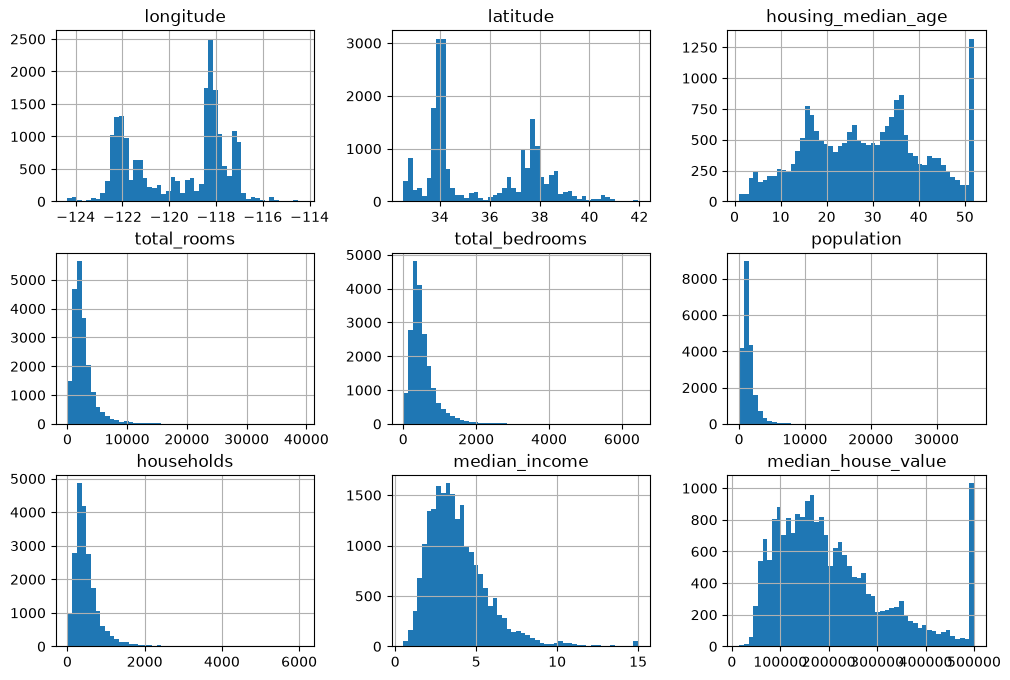

In [6]:
housing.hist(bins=50, figsize=(12, 8))
plt.show()

# Task 3.1 – Attribute Distributions

**1. Which attributes have approximately symmetric distributions?**
**Answer:** `median_income` looks the most symmetrical in terms of distribution.

**2. Which attributes are strongly skewed?**
**Answer:** `total_rooms` , `total_bedrooms` , `population` , and `households`

**3. Are there attributes with very different numerical scales?**
**Answer:** Yes! from `housing.describe()`, `median_income` has a max of 15 and `total_rooms` has a max of 39320. In ratio that's 39320 / 15 =  2621.3.

**4. Are there unusually large or small values?**
**Answer:** Yes! `housing_median_age`, and `median_house_value` plots stops at 52 and 500001 respectively. The bars are tallest at those two points and it shows there is more load there and possible cutting off values above limit. This is bad for our target which is `median_house_value` cause of the value tht might have been cut off.

In [7]:
train_set, test_set = train_test_split(
    housing,
    test_size=0.2,
    random_state=42
)

print(len(train_set), len(test_set))

16512 4128


# Task 4.1 – Why Separate the Data?

**1. Why do we need a test set?**
**Answer:** We need test set to determine whether our model will work on data it has never seen before.

**2. What could happen if we repeatedly use the test set while developing the model?**
**Answer:** If we use test set while developing the model then its called "data snooping", and this makes the model unriable in real world scenarios or unseen data. 

**3. Why should preprocessing operations also be learned from the training data rather than
the complete dataset?**
**Answer:** We should learn preprocessing operations from the training data to prevent data leakage. For example if the median is calculated from the whole dataset, it is influenced by the test data, and that median is then used on the training data.


In [8]:
housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0., 1.5, 3., 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)

housing["income_cat"].value_counts()

income_cat
3    7236
2    6581
4    3639
5    2362
1     822
Name: count, dtype: int64

In [9]:
split = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

print(len(strat_train_set), len(strat_test_set))

16512 4128


In [10]:
train_set, test_set = train_test_split(
    housing,
    test_size=0.2,
    random_state=42
)

In [11]:
print("Overall:")
print(housing["income_cat"].value_counts(normalize=True).sort_index())

print("\nStratified test set:")
print(strat_test_set["income_cat"].value_counts(normalize=True).sort_index())

print("\nRandom test set:")
print(test_set["income_cat"].value_counts(normalize=True).sort_index())

Overall:
income_cat
1    0.039826
2    0.318847
3    0.350581
4    0.176308
5    0.114438
Name: proportion, dtype: float64

Stratified test set:
income_cat
1    0.039971
2    0.318798
3    0.350533
4    0.176357
5    0.114341
Name: proportion, dtype: float64

Random test set:
income_cat
1    0.042393
2    0.307413
3    0.345203
4    0.184109
5    0.120882
Name: proportion, dtype: float64


# Task 5.1 – Compare Sampling Strategies

**1. Compare the income distribution obtained using:
• random sampling, and
• stratified sampling.**
**Answer:** The stratified sampling is closer in value to the overall than the random sampling. In category 2 for example, the overall is 0.318847, the stratified test set is 0.318798 which is approximately same, unlike the value on the same category 2 for random test set which is 0.307413 whcih shows a drift compared to the stratified.

**2. Why might stratified sampling be preferable when an attribute has an important relationship
with the target variable?**
**Answer:** The stratified sampling samples the test set in proportion, rather that of the random whick is purely like a game of luck. This matters most because our target, `median_house_value` is tied closely to `median_income`. So, if the test has a lot of drif from the median income mix, it is going to affect the hosue value. Also for exmaple in our dataset where the `ocean_proximity`  has the "ISLAND" option occuring just 5 times. Stratified makes sure to cover at least one of these values, but random has the probability not to cover any of them, which makes the final score unreliable.

In [12]:
for subset in (strat_train_set, strat_test_set):
    subset.drop("income_cat", axis=1, inplace=True)

print(strat_train_set.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


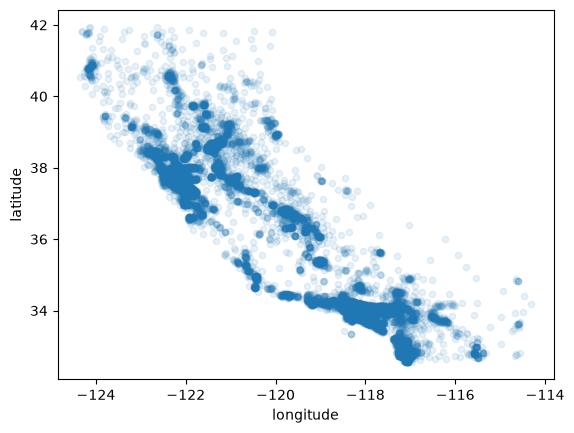

In [13]:
housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.1
)
plt.show()

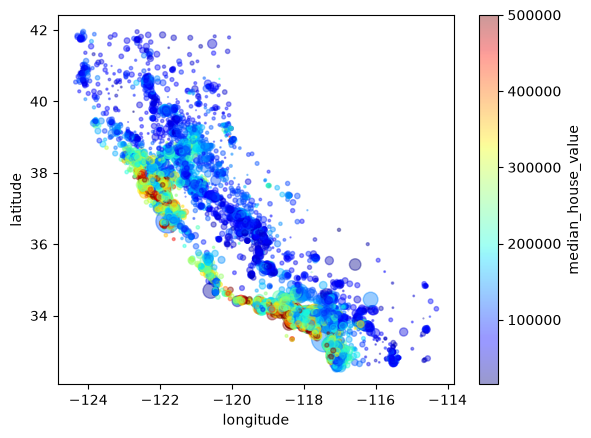

In [14]:
housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.4,
    s=housing["population"] / 100,
    c="median_house_value",
    cmap=plt.get_cmap("jet"),
    colorbar=True
)
plt.show()

# Task 6.1 – Interpret the Visualization

**1. What geographical patterns can you observe?**
**Answer:** I can observe the distribution from top top left running through the bottom right. More densed towards the west and sparse towards the east.

**2. Where are the high-density areas?**
**Answer:** The high density areas are latitude 34, 36-38 and then longitude -124 to -122 and then also -120 to -118

**3. Do house values appear to vary geographically?**
**Answer:** Yes they vary as seen in the plot you have more expensive houses around (latitude 34, and beatween longitude (-120 and -117)) also seen at longitude -122 and latitude between (36 and 38). then less expensive house shaded in blue

**4. Why could geographical information be useful for predicting house prices?**
**Answer:** It is useful because the positions on the plots make it easier to predict house prices. If the position of a district is at the orange, red region then it means houses in that district are expensive. so data like this helps the model predict better.

In [15]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

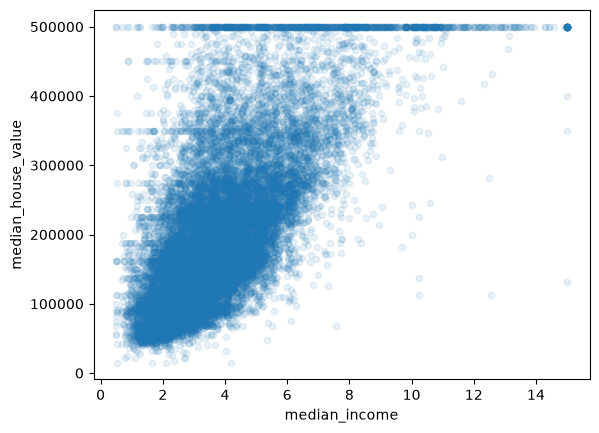

In [16]:
housing.plot(
    kind="scatter",
    x="median_income",
    y="median_house_value",
    alpha=0.1
)
plt.show()

# Task 7.1 – Interpret Correlations

**1. Which attribute has the strongest correlation with median house value?**
**Answer:** `median_income` has the strongest correlation as it has the highest value of 0.688 compared to the other numerical attributes. This is also because in real world sense, the higher the income the higher the chance of higher house value.

**2. Does a strong correlation necessarily mean that one attribute causes the target to change?**
**Answer:** No. correlation only shows the possibibility fo to things moving together and not  one thing out of two things causng the change of the other. For example buying hot chocolate and buying winter coat correlate (they move together) but each does not cause the other (buying winter coat doesnt make you buy hot chocolate). They move together because of one hidden cause which is winter.

**3. Are there attributes with weak correlation that might still be useful?**
**Answer:** Yes. Location too is a factor that can affect the price of a house, like in the case of the `latitude` being -0.144 it is a weak correlation because correlation measures in striagh line but locaion (latitude and longitude) are not neccesary straight as it goes up and down.

**4. Can correlation alone be used to select the final machine learning model?**
**Answer:** No, correlation only works with two columns. For  a complete machine learning model, all attributes (columns) are needed for both training and testing. Correlation only makes you understand your data better.

In [17]:
housing["rooms_per_household"] = (
    housing["total_rooms"] /
    housing["households"]
)

housing["bedrooms_per_room"] = (
    housing["total_bedrooms"] /
    housing["total_rooms"]
)

housing["population_per_household"] = (
    housing["population"] /
    housing["households"]
)

In [18]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151948
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049686
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64

# Task 8.1 – Feature Engineering Discussion

**1. Why can combining existing attributes be useful?**
**Answer:** `total_rooms` is generally covering the row (district), but the new `rooms_per_household` column (attribute) we added shows more clarity and give more insights on each household which in turn helps predict hosue values. Using an expale of of two schools A and B. School A has 1000 students and 2000 supply of pen. School B has 100 students and 500 supply of pens. At a glance you see School A as the bigger school with more stduents and more pens but if you calculate the ratio of pens to stduent you find out school A has 2 pens per student while school B has 5 pens per student.

**2. Which engineered attribute appears most promising?**
**Answer:** `bedrooms_per_room` appears most promising. One being that it has the enxt strongest correlation after `median_income`. See the old attribute, `total_bedrooms` of 0.049 ~ 0.05 is less than `bedrooms_per_room` which is -0.255 ~ 0.26. (Ignore the negative sign). The share of bedrooms per rooms in a household can speak to the value of wealth of a household which in turn can help predict the house value.

**3. What could happen if we create too many unnecessary features?**
**Answer:** More unnemesary columns can make the model slower and less efficient. Unneccesary features can make the model learn wrong patterns, like the `population_per_household` which is -0.024 and the `population` whcih is -0.025. They arealmsot same and irrelevant in this case. it can be useful if you want to actually know the population per every household but not neccessarily useful for our target which is `median_house_value`.

In [19]:
housing.isnull().sum()

longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms              207
population                    0
households                    0
median_income                 0
median_house_value            0
ocean_proximity               0
income_cat                    0
rooms_per_household           0
bedrooms_per_room           207
population_per_household      0
dtype: int64

In [20]:
imputer = SimpleImputer(strategy="median")

housing_num = strat_train_set.drop("ocean_proximity", axis=1)
print(housing_num.columns.tolist())

imputer.fit(housing_num)

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']


,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','median_house_value']"
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[float64](9,)","[ -118.51, 34.26, 29. ,..., 408. , 3.54,179200. ]"


In [21]:
imputer.statistics_

array([-1.1851e+02,  3.4260e+01,  2.9000e+01,  2.1250e+03,  4.3400e+02,
        1.1670e+03,  4.0800e+02,  3.5385e+00,  1.7920e+05])

In [22]:
X = imputer.transform(housing_num)

# Task 9.1 – Compare Missing-Value Strategies

Briefly discuss the advantages and disadvantages of:

**• deleting rows**
**Answer:** The advantage of deleting a row  (with Null values) is that you all your data becomes real and no guess values. The disadvnatge is that you loose useful data from other columns in that row.

**• deleting an attribute**
**Answer:** Similar to delting the row you have an advantage of neat and real data but a disadvantage of loosing that that particular column, because of some few missing values. You will also loose the new engineered columns like like `bedrooms_per_room` because it is built from `total_bedrooms` which have 207 missing values.

**• replacing missing values with the median.**
**Answer:** The advantge to this si that no row or column is lost as they are all included in training and testing the model. The disavantage is that it that you still fill those holes with estimated values because the median isnt actually the real value suppsoed to be there but a more efficient placeholder.

**Question: Why is it important to calculate the median from the training data rather than from
the complete dataset?**
**Answer:** This is cause of data leakage if you calculate the median with the complete data (training and test), the median will be influenced by the test data which is meant to be unknown and unseen.

In [23]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [24]:
cat_encoder = OneHotEncoder()
housing_cat = strat_train_set[["ocean_proximity"]]
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [25]:
print(cat_encoder.categories_)
print(housing_cat_1hot.shape)
housing_cat_1hot.toarray()[:5]

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]
(16512, 5)


array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

# Task 10.1 – Understand One-Hot Encoding

Explain:

**1. Why cannot we simply assign the categories the values 1, 2, 3, and so on?**
**Answer:** The `ocean_proximity` values are nominal and cannot be represented numerically, as an ordered list of numbers. This will make the mdoel think that one category is bigger than the other, which is false.

**2. What does one-hot encoding achieve?**
**Answer:** one-hot encoding turns each category into its own columns of 0's and 1's therby making each category equally and identically different from each other.

**3. How many encoded features are created for the ocean_proximity attribute?**
**Answer:** 5 encoded features are created. 1 column for each category.

In [26]:
scaler = StandardScaler()
housing_num_scaled = scaler.fit_transform(housing_num)

In [27]:
pd.DataFrame(
    housing_num_scaled,
    columns=housing_num.columns
).describe().loc[["mean", "std"]].round(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
mean,-0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


# Task 11.1 – Understand Feature Scaling

Answer:

**1. Why can different feature scales be a problem for some ML algorithms?**
**Answer:** Some models compare attribute values by their sizes. so attributes with alrger values like for example `total_rooms` of 39320 will dominate an attribute `median_income` of value 15, even when `median_income` is more important for our target. In order words models is tricked by bigger numbers instead of their importance.

**2. What does standardization do?**
**Answer:** Standardization solves the problem in question 1, by making attiribute values similar and closer in size. So for each column value, it substracts the mean and divides by the standard deviation so all columns end up in the same size range.

**3. Does feature scaling change the information contained in the data?**
**Answer:** No it doesnt change the information. It only changes the unit value. In every column the biggest will still remain the biggest even after scaling and vice versa.

**4. Is feature scaling required for every machine learning algorithm?**
**Answer:** No, Some models dont need scaling. Models that deals with distance need scaling. Decision trees doent need scaling as for example yes or no output wil still be yes or now regardless.

In [28]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

housing_num = housing.drop("ocean_proximity", axis=1)
housing_cat = housing[["ocean_proximity"]]

print(housing.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']


In [29]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [30]:
num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs)
])

In [31]:
housing_prepared = full_pipeline.fit_transform(housing)

In [32]:
print(housing_prepared.shape)
print(full_pipeline.get_feature_names_out())

(16512, 13)
['num__longitude' 'num__latitude' 'num__housing_median_age'
 'num__total_rooms' 'num__total_bedrooms' 'num__population'
 'num__households' 'num__median_income' 'cat__ocean_proximity_<1H OCEAN'
 'cat__ocean_proximity_INLAND' 'cat__ocean_proximity_ISLAND'
 'cat__ocean_proximity_NEAR BAY' 'cat__ocean_proximity_NEAR OCEAN']


# Task 12.1 – Understand the Pipeline

**Explain the sequence of operations performed by the pipeline.**
**Answer:** Just like a recipe step in coking a meal, here is the sequence for pipeline operations: data is split into number columns and the text column, then if the number columns have missing datas, they are filled up with the median fo the training dataset and then scaled. Then the text column is one-hot encoded, after which both number and text columns are joined into one table.

In particular, identify:

**1. Where missing numerical values are handled.**
**Answer:** missing values were handled in the `SimpleImputer()` function  step that replaces the missing values with the median of the training dataset. inside `num_pipeline`

**2. Where numerical features are scaled.**
**Answer:** numerical values are scaled in the `StandardScaler()` function still inside the `num_pipeline`. the msising avlues are filled before the scaling.

**3. Where categorical features are encoded.**
**Answer:** In the `ColumnTransformer()` specifically the `OneHotEncoder()` function.

**4. Why using a pipeline is preferable to manually repeating the preprocessing operations.**
**Answer:** It simply reduces mistakes that can occur while repeating prepocessing manually, it saves time, keeps the work neat, tidy and organized. Most importantl it prevents data leakage.